# Notebook 07 — Task Classification

Train and evaluate two classifiers — Naive Bayes and LinearSVC — on TF-IDF features for both task type and priority prediction. Outputs are saved models and a predictions CSV for downstream evaluation in notebook 09.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

PROCESSED_DIR = '../data/processed/'
MODELS_DIR    = '../models/'
REPORTS_DIR   = '../reports/figures/'

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

## Step 1 — Load and Verify

Load all four matrices and four label arrays saved by notebook 05. No model training, no transformations — only confirmations:

- **Shape check** — rows in `X_train_tfidf` must exactly equal the length of both `y_train_type` and `y_train_priority`. Same for test. Any mismatch means the split indices are misaligned and must be traced back to notebook 05.
- **Label content check** — `value_counts()` for all four label arrays. Must match the balanced distributions confirmed in notebook 05. Unexpected skew means `squeeze()` was not applied when loading single-column CSVs, converting the Series to a DataFrame silently.
- **Sparse matrix check** — `X_train_tfidf` must be a scipy sparse matrix, not a dense array. Loading as dense is a memory waste but does not break functionality.
- **Feature count reminder** — print `X_train_tfidf.shape[1]`; this is the dimensionality LinearSVC will operate in.

In [2]:
# --- load matrices ---
X_train = scipy.sparse.load_npz(PROCESSED_DIR + 'X_train_tfidf.npz')
X_test  = scipy.sparse.load_npz(PROCESSED_DIR + 'X_test_tfidf.npz')

# --- load labels (squeeze: single-column CSV → Series, not DataFrame) ---
y_train_type     = pd.read_csv(PROCESSED_DIR + 'y_train_type.csv',     index_col=0).squeeze()
y_test_type      = pd.read_csv(PROCESSED_DIR + 'y_test_type.csv',      index_col=0).squeeze()
y_train_priority = pd.read_csv(PROCESSED_DIR + 'y_train_priority.csv', index_col=0).squeeze()
y_test_priority  = pd.read_csv(PROCESSED_DIR + 'y_test_priority.csv',  index_col=0).squeeze()

# --- shape verification ---
print('=== SHAPE VERIFICATION ===\n')
print(f'X_train          : {X_train.shape}')
print(f'X_test           : {X_test.shape}')
print(f'y_train_type     : {y_train_type.shape}')
print(f'y_test_type      : {y_test_type.shape}')
print(f'y_train_priority : {y_train_priority.shape}')
print(f'y_test_priority  : {y_test_priority.shape}')

assert X_train.shape[0] == len(y_train_type) == len(y_train_priority), \
    'Train row count mismatch — trace back to notebook 05'
assert X_test.shape[0]  == len(y_test_type)  == len(y_test_priority),  \
    'Test row count mismatch — trace back to notebook 05'
print('\n✓ Row counts aligned for both train and test sets')

# --- sparse matrix check ---
print(f'\n=== SPARSE MATRIX TYPE ===')
print(f'type(X_train) : {type(X_train)}')
print(f'type(X_test)  : {type(X_test)}')

# --- feature count ---
print(f'\n=== FEATURE DIMENSIONALITY ===')
print(f'TF-IDF features : {X_train.shape[1]:,}')
print(f'(LinearSVC will search for separating hyperplanes in this space)')

# --- label content ---
print('\n=== LABEL DISTRIBUTIONS ===')
print('\ny_train_type:')
print(y_train_type.value_counts().to_string())
print('\ny_test_type:')
print(y_test_type.value_counts().to_string())
print('\ny_train_priority:')
print(y_train_priority.value_counts().to_string())
print('\ny_test_priority:')
print(y_test_priority.value_counts().to_string())

=== SHAPE VERIFICATION ===

X_train          : (6461, 1306)
X_test           : (1616, 1306)
y_train_type     : (6461,)
y_test_type      : (1616,)
y_train_priority : (6461,)
y_test_priority  : (1616,)

✓ Row counts aligned for both train and test sets

=== SPARSE MATRIX TYPE ===
type(X_train) : <class 'scipy.sparse._csr.csr_matrix'>
type(X_test)  : <class 'scipy.sparse._csr.csr_matrix'>

=== FEATURE DIMENSIONALITY ===
TF-IDF features : 1,306
(LinearSVC will search for separating hyperplanes in this space)

=== LABEL DISTRIBUTIONS ===

y_train_type:
task_type
refund request          1327
technical issue         1321
cancellation request    1295
product inquiry         1261
billing inquiry         1257

y_test_type:
task_type
refund request          332
technical issue         330
cancellation request    324
product inquiry         316
billing inquiry         314

y_train_priority:
priority
medium      1675
critical    1631
high        1586
low         1569

y_test_priority:
priority
high

## Step 2 — Evaluation Metrics

**Why accuracy alone is insufficient:**

Accuracy gives the overall proportion correct. For our balanced 5-class task type problem it is a fair headline number — random baseline is 20%. But it hides per-class blind spots.

The classification report gives precision, recall, and F1 for every class:

| Metric | Question it answers | Why it matters |
|---|---|---|
| **Precision** (per class) | Of all tickets the model labelled as *X*, what fraction actually were *X*? | Low precision = too many false alarms for that class |
| **Recall** (per class) | Of all actual *X* tickets, what fraction did the model catch? | Low recall = the model misses many tickets of that class |
| **F1** | Harmonic mean of precision and recall | Use for per-class comparison — penalises both false alarms and misses |
| **Macro F1** | Unweighted average F1 across all classes | Primary comparison metric — treats all classes equally regardless of size |

**Random baselines:**
- Task type (5 balanced classes) → 20% accuracy / 0.20 macro F1
- Priority (4 balanced classes) → 25% accuracy / 0.25 macro F1

Any model that does not beat these baselines on macro F1 has failed to find signal.

## Step 3 — Experiment 1: Naive Bayes on TF-IDF (Task Type)

**Why start with Naive Bayes:**
Naive Bayes is the floor. It answers: do TF-IDF features contain any classification signal at all? If Naive Bayes cannot beat 20% random baseline, the features have failed — go back to preprocessing.

Naive Bayes learns P(word | class) for every vocabulary term. For our data it calculates things like: given that a ticket contains *hardware*, how likely is it to be a technical issue versus a billing inquiry? It multiplies individual word probabilities and picks the highest-scoring class.

The independence assumption — each word contributes independently — is mathematically wrong for language but works surprisingly well for text classification because even independent word probabilities carry useful signal.

**Alpha smoothing:** `alpha=1.0` is standard Laplace smoothing. It prevents zero probabilities for words that appear in the test set but never co-occurred with a particular class in training. We also test `alpha=0.1` — tighter smoothing that trusts the training distribution more aggressively.

In [3]:
nb_results = {}

for alpha in [1.0, 0.1]:
    nb = MultinomialNB(alpha=alpha)
    nb.fit(X_train, y_train_type)
    y_pred = nb.predict(X_test)

    acc   = accuracy_score(y_test_type, y_pred)
    report = classification_report(y_test_type, y_pred, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']

    nb_results[alpha] = {'model': nb, 'y_pred': y_pred, 'accuracy': acc, 'macro_f1': macro_f1}

    print(f'=== Naive Bayes  alpha={alpha} ===')
    print(f'Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
    print(f'Macro F1  : {macro_f1:.4f}')
    print(f'Improvement over 20% baseline: +{(acc - 0.20)*100:.1f}pp')
    print()
    print(classification_report(y_test_type, y_pred))
    print()

=== Naive Bayes  alpha=1.0 ===
Accuracy  : 0.2024  (20.2%)
Macro F1  : 0.2009
Improvement over 20% baseline: +0.2pp

                      precision    recall  f1-score   support

     billing inquiry       0.19      0.14      0.16       314
cancellation request       0.22      0.20      0.21       324
     product inquiry       0.21      0.24      0.23       316
      refund request       0.19      0.22      0.20       332
     technical issue       0.20      0.22      0.21       330

            accuracy                           0.20      1616
           macro avg       0.20      0.20      0.20      1616
        weighted avg       0.20      0.20      0.20      1616


=== Naive Bayes  alpha=0.1 ===
Accuracy  : 0.2048  (20.5%)
Macro F1  : 0.2039
Improvement over 20% baseline: +0.5pp

                      precision    recall  f1-score   support

     billing inquiry       0.21      0.16      0.18       314
cancellation request       0.22      0.19      0.21       324
     product inqu

## Step 4 — Experiment 2: LinearSVC on TF-IDF (Task Type)

**Why LinearSVC is the primary model:**
LinearSVC finds the optimal separating hyperplane for each class in the 1,380-dimensional TF-IDF feature space. Unlike Naive Bayes which treats words independently, LinearSVC learns weights for feature combinations — it discovers that *hardware* AND *software* AND *error* together strongly predict technical issue even when each word alone is insufficient.

The PCA visualisation in notebook 05 showed overlap in 2D. But PCA retained only ~14% of variance when projecting to 2 dimensions. LinearSVC operates in all 1,380 dimensions — the high-dimensional space may have clear boundaries completely invisible in any 2D projection.

**C parameter — regularisation strength:**

| C value | Behaviour | Risk |
|---|---|---|
| `C=10` | Tries very hard to classify every training ticket correctly, including noisy ones | Overfits to template artifacts |
| `C=1.0` | Balanced starting point | Default |
| `C=0.5` | Accepts more training errors for a more generalizable boundary | May underfit |
| `C=0.1` | Strongly regularised — best for noisy / templated data | May underfit |

Our data has template contamination. Test three values (0.1, 0.5, 1.0) and pick the one with highest test accuracy without a large train/test gap.

**Convergence:** Set `max_iter=2000` upfront. A `ConvergenceWarning` means the optimizer did not fully solve the problem and results may be suboptimal — increase to 5000 if seen.

In [4]:
svc_results = {}

for C in [0.1, 0.5, 1.0]:
    svc = LinearSVC(C=C, max_iter=2000, random_state=42)
    svc.fit(X_train, y_train_type)
    y_pred_train = svc.predict(X_train)
    y_pred_test  = svc.predict(X_test)

    train_acc = accuracy_score(y_train_type, y_pred_train)
    test_acc  = accuracy_score(y_test_type,  y_pred_test)
    report    = classification_report(y_test_type, y_pred_test, output_dict=True)
    macro_f1  = report['macro avg']['f1-score']

    svc_results[C] = {
        'model': svc, 'y_pred': y_pred_test,
        'train_acc': train_acc, 'test_acc': test_acc, 'macro_f1': macro_f1
    }

    print(f'LinearSVC  C={C}')
    print(f'  Train accuracy : {train_acc:.4f}  ({train_acc*100:.1f}%)')
    print(f'  Test  accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
    print(f'  Macro F1       : {macro_f1:.4f}')
    gap = train_acc - test_acc
    print(f'  Train/test gap : {gap:+.4f}  ({"acceptable" if gap < 0.08 else "possible overfit — try lower C"})')
    print()

# pick best C by test accuracy
best_C = max(svc_results, key=lambda c: svc_results[c]['test_acc'])
best_svc  = svc_results[best_C]['model']
best_pred = svc_results[best_C]['y_pred']

print(f'=== Best C = {best_C} — Full Classification Report ===')
print(classification_report(y_test_type, best_pred))

LinearSVC  C=0.1
  Train accuracy : 0.4024  (40.2%)
  Test  accuracy : 0.1955  (19.6%)
  Macro F1       : 0.1947
  Train/test gap : +0.2069  (possible overfit — try lower C)

LinearSVC  C=0.5
  Train accuracy : 0.4473  (44.7%)
  Test  accuracy : 0.1943  (19.4%)
  Macro F1       : 0.1943
  Train/test gap : +0.2530  (possible overfit — try lower C)

LinearSVC  C=1.0
  Train accuracy : 0.4553  (45.5%)
  Test  accuracy : 0.1937  (19.4%)
  Macro F1       : 0.1936
  Train/test gap : +0.2617  (possible overfit — try lower C)

=== Best C = 0.1 — Full Classification Report ===
                      precision    recall  f1-score   support

     billing inquiry       0.18      0.15      0.16       314
cancellation request       0.20      0.19      0.19       324
     product inquiry       0.21      0.22      0.22       316
      refund request       0.18      0.20      0.19       332
     technical issue       0.20      0.22      0.21       330

            accuracy                           0.20

## Step 5 — Reading the Results

After numbers exist, think through them systematically:

1. **Both models vs random baseline** — Any model below 20% accuracy or 0.20 macro F1 has failed entirely.
2. **Per-class F1 from LinearSVC** — Expected pattern based on vocabulary analysis:
   - *technical issue* — likely highest F1: distinctive vocabulary (hardware, software, error, bug, device, network, compatibility) rarely appears in billing or refund tickets.
   - *billing inquiry* — likely lowest F1: billing vocabulary (billing, payment, invoice) may not be distinctive enough after preprocessing.
   - *refund request* vs *cancellation request* — likely confused: customers wanting a refund and customers wanting to cancel a subscription use similar language. Expect the confusion matrix to show cross-predictions between these two specifically.
3. **Confusion matrix** — read each row as: "for tickets actually labelled X, where does the model send them?" A row spread evenly across columns = the model cannot classify that class. A row mostly on the diagonal with a few off-diagonal = good classification with predictable error patterns.

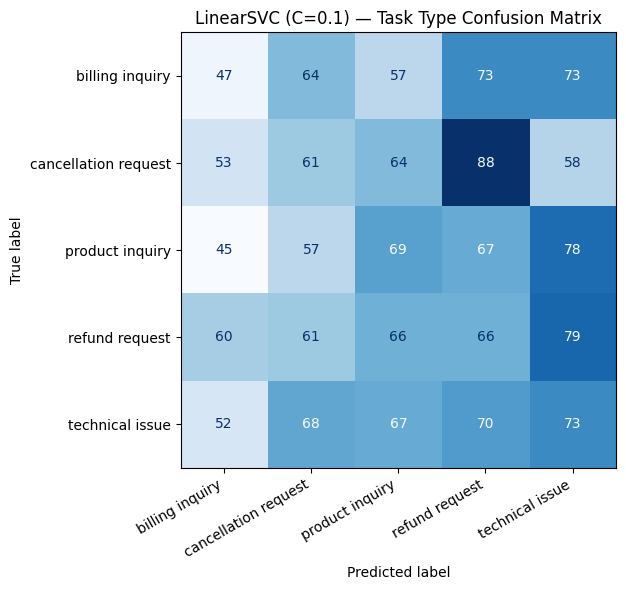

Saved: confusion_matrix_task_type.png


In [5]:
classes = sorted(y_test_type.unique())
cm = confusion_matrix(y_test_type, best_pred, labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'LinearSVC (C={best_C}) — Task Type Confusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'confusion_matrix_task_type.png', dpi=150)
plt.show()
print('Saved: confusion_matrix_task_type.png')

## Step 6 — Error Analysis

Fifteen minutes here significantly elevates project quality. The confusion matrix shows where errors occur — error analysis shows *why*.

**Process:** Build a DataFrame of misclassified test tickets with their true label, predicted label, and original `clean_text`. Sample from the most common confusion pair (whichever two classes have the most cross-predictions in the matrix). For each misclassified example, ask:

1. As a human reading this, would I classify it correctly? If yes — the model failed where a human would not. That is a feature gap.
2. As a human, would I also find it ambiguous? If yes — inherently difficult case even the best model might miss.
3. Does the ticket text contain vocabulary from the *predicted* class? If a refund ticket was predicted as cancellation, does it mention cancellation-related words? If yes, the model's reasoning was at least partially justified.

These three questions turn raw accuracy numbers into a narrative about why the model performs the way it does.

In [6]:
# reload original clean_text aligned to test indices
preprocessed = pd.read_csv('../data/processed/preprocessed_tasks.csv', index_col=None)
preprocessed.index = range(len(preprocessed))

test_indices = y_test_type.index.tolist()
clean_text_test = preprocessed.loc[test_indices, 'clean_text'].reset_index(drop=True)
y_test_reset     = y_test_type.reset_index(drop=True)
y_pred_reset     = pd.Series(best_pred, name='predicted')

errors_df = pd.DataFrame({
    'clean_text': clean_text_test,
    'true_label': y_test_reset,
    'predicted' : y_pred_reset
})
errors_df = errors_df[errors_df['true_label'] != errors_df['predicted']].reset_index(drop=True)

print(f'Total misclassified tickets: {len(errors_df)} / {len(y_test_type)}  '
      f'({len(errors_df)/len(y_test_type)*100:.1f}%)')
print()

# most common confusion pair
confusion_pairs = errors_df.groupby(['true_label', 'predicted']).size().sort_values(ascending=False)
print('=== TOP 5 CONFUSION PAIRS ===')
print(confusion_pairs.head(10).to_string())

top_pair = confusion_pairs.index[0]
print(f'\n=== SAMPLE MISCLASSIFICATIONS: true={top_pair[0]!r}  predicted={top_pair[1]!r} ===')
sample = errors_df[
    (errors_df['true_label'] == top_pair[0]) &
    (errors_df['predicted']  == top_pair[1])
].head(5)
for i, row in sample.iterrows():
    print(f'\n[{i}] TRUE: {row["true_label"]}  |  PREDICTED: {row["predicted"]}')
    print(f'     {row["clean_text"][:300]}')

Total misclassified tickets: 1300 / 1616  (80.4%)

=== TOP 5 CONFUSION PAIRS ===
true_label            predicted           
cancellation request  refund request          88
refund request        technical issue         79
product inquiry       technical issue         78
billing inquiry       technical issue         73
                      refund request          73
technical issue       refund request          70
                      cancellation request    68
                      product inquiry         67
product inquiry       refund request          67
refund request        product inquiry         66

=== SAMPLE MISCLASSIFICATIONS: true='cancellation request'  predicted='refund request' ===

[1] TRUE: cancellation request  |  PREDICTED: refund request
     installation support im having an issue with the please assist this problem started occurring after the recent software update i havent made any other changes to the device

[21] TRUE: cancellation request  |  PREDICTED: refund

## Step 7 — Experiment 3: Priority Prediction with LinearSVC

**Critical thinking before running:**
The EDA heatmap showed that every ticket type has roughly equal distribution across all 4 priority levels — critical, high, medium, low appear with similar frequency in every type. This means the text features that helped classify ticket types may not help classify priorities.

What text signals would indicate priority? A critical ticket might use urgency language: *urgent*, *immediately*, *broken*, *cannot work*, *production down*. A low priority ticket might use softer language: *wondering*, *curious*, *when possible*. The question is whether these signals survived preprocessing — detemplatization specifically removed persistence phrases that might encode urgency.

**What to expect:**
- Random baseline: 25% (4 balanced classes)
- LinearSVC range: 28–40%
- If below 30%: TF-IDF text features are insufficient for priority — Week 3 must add structured features (customer age, product type, channel) alongside text to improve with Random Forest / XGBoost
- If above 45%: investigate coefficient weights — the text features carry more priority signal than EDA suggested

In [7]:
priority_results = {}

for C in [0.1, 0.5, 1.0]:
    svc_p = LinearSVC(C=C, max_iter=2000, random_state=42)
    svc_p.fit(X_train, y_train_priority)
    y_pred_p = svc_p.predict(X_test)

    acc_p    = accuracy_score(y_test_priority, y_pred_p)
    report_p = classification_report(y_test_priority, y_pred_p, output_dict=True)
    macro_f1_p = report_p['macro avg']['f1-score']

    priority_results[C] = {
        'model': svc_p, 'y_pred': y_pred_p,
        'accuracy': acc_p, 'macro_f1': macro_f1_p
    }
    print(f'LinearSVC (priority)  C={C}')
    print(f'  Accuracy  : {acc_p:.4f}  ({acc_p*100:.1f}%)')
    print(f'  Macro F1  : {macro_f1_p:.4f}')
    print(f'  vs 25% baseline: +{(acc_p - 0.25)*100:.1f}pp')
    print()

best_C_p    = max(priority_results, key=lambda c: priority_results[c]['accuracy'])
best_svc_p  = priority_results[best_C_p]['model']
best_pred_p = priority_results[best_C_p]['y_pred']

print(f'=== Best C = {best_C_p} — Full Classification Report (Priority) ===')
print(classification_report(y_test_priority, best_pred_p))

LinearSVC (priority)  C=0.1
  Accuracy  : 0.2710  (27.1%)
  Macro F1  : 0.2697
  vs 25% baseline: +2.1pp

LinearSVC (priority)  C=0.5
  Accuracy  : 0.2593  (25.9%)
  Macro F1  : 0.2584
  vs 25% baseline: +0.9pp

LinearSVC (priority)  C=1.0
  Accuracy  : 0.2605  (26.1%)
  Macro F1  : 0.2599
  vs 25% baseline: +1.1pp

=== Best C = 0.1 — Full Classification Report (Priority) ===
              precision    recall  f1-score   support

    critical       0.26      0.26      0.26       399
        high       0.29      0.26      0.27       415
         low       0.27      0.24      0.25       387
      medium       0.27      0.33      0.29       415

    accuracy                           0.27      1616
   macro avg       0.27      0.27      0.27      1616
weighted avg       0.27      0.27      0.27      1616



## Step 8 — Feature Importance from LinearSVC

LinearSVC learns a weight for every feature for every class. A large positive weight for a term in the *technical issue* class means that term strongly pushes predictions toward *technical issue*. A large negative weight pushes predictions away from that class.

**What to look for:**
- *technical issue* top positive features → should be: software, hardware, device, error, network, bug. If yes, the model reasons correctly.
- *billing inquiry* top features → should include: billing, payment, charge, invoice. If generic words appear instead, billing vocabulary is not distinctive enough.
- *refund request* top features → should include: refund, return, money. If *cancellation* appears as a top feature for refund, it confirms vocabulary overlap between those two classes.

This chart is one of the most presentable outputs of the project — directly understandable to any audience, technical or not.

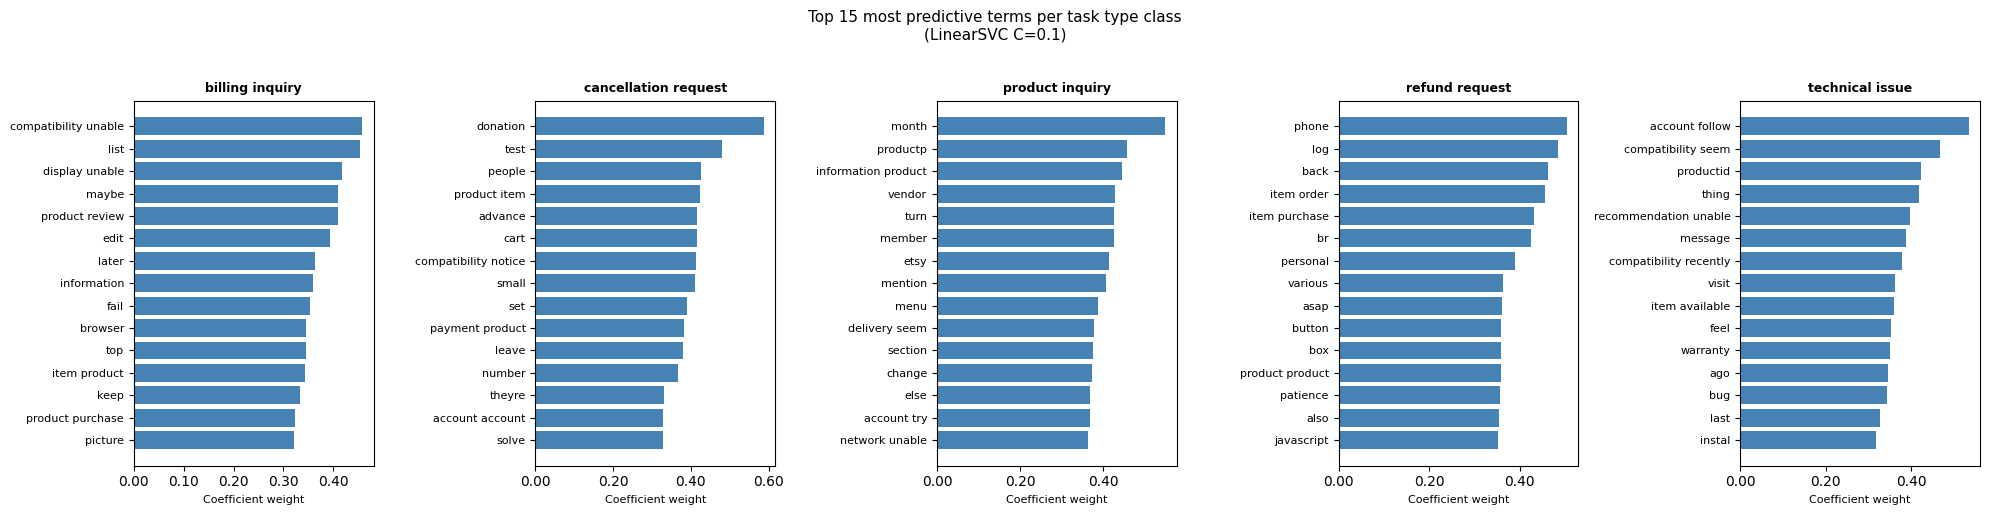

Saved: feature_importance_task_type.png


In [8]:
vectorizer = joblib.load(MODELS_DIR + 'tfidf_vectorizer.pkl')
feature_names = vectorizer.get_feature_names_out()
classes_ordered = best_svc.classes_
TOP_N = 15

fig, axes = plt.subplots(1, len(classes_ordered), figsize=(20, 5), sharey=False)

for ax, cls_name, coef in zip(axes, classes_ordered, best_svc.coef_):
    top_idx = np.argsort(coef)[-TOP_N:][::-1]
    top_terms  = feature_names[top_idx]
    top_weights = coef[top_idx]

    bars = ax.barh(range(TOP_N), top_weights[::-1], color='steelblue')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_terms[::-1], fontsize=8)
    ax.set_title(cls_name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Coefficient weight', fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.suptitle(f'Top {TOP_N} most predictive terms per task type class\n(LinearSVC C={best_C})',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'feature_importance_task_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_task_type.png')

## Step 9 — Final Comparison Table

A clean summary of all experiments with improvement over random baseline.

In [9]:
print('=' * 72)
print('TASK TYPE CLASSIFICATION SUMMARY  (5 classes, random baseline = 20%)')
print('=' * 72)
print(f'{"Model":<30} {"Accuracy":>10} {"Macro F1":>10} {"vs Baseline":>12}')
print('-' * 72)
print(f'{"Random Baseline":<30} {0.200:>10.3f} {0.200:>10.3f} {"—":>12}')

for alpha in [1.0, 0.1]:
    r = nb_results[alpha]
    label = f'Naive Bayes (alpha={alpha})'
    print(f'{label:<30} {r["accuracy"]:>10.3f} {r["macro_f1"]:>10.3f} '
          f'{f"+{(r["accuracy"]-0.20)*100:.1f}pp":>12}')

for C in [0.1, 0.5, 1.0]:
    r = svc_results[C]
    label = f'LinearSVC (C={C})'
    marker = ' ←best' if C == best_C else ''
    print(f'{label:<30} {r["test_acc"]:>10.3f} {r["macro_f1"]:>10.3f} '
          f'{f"+{(r["test_acc"]-0.20)*100:.1f}pp":>12}{marker}')

print()
print('=' * 72)
print('PRIORITY PREDICTION SUMMARY  (4 classes, random baseline = 25%)')
print('=' * 72)
print(f'{"Model":<30} {"Accuracy":>10} {"Macro F1":>10} {"vs Baseline":>12}')
print('-' * 72)
print(f'{"Random Baseline":<30} {0.250:>10.3f} {0.250:>10.3f} {"—":>12}')

for C in [0.1, 0.5, 1.0]:
    r = priority_results[C]
    label = f'LinearSVC (C={C})'
    marker = ' ←best' if C == best_C_p else ''
    print(f'{label:<30} {r["accuracy"]:>10.3f} {r["macro_f1"]:>10.3f} '
          f'{f"+{(r["accuracy"]-0.25)*100:.1f}pp":>12}{marker}')

print()
type_best = svc_results[best_C]['test_acc']
pri_best  = priority_results[best_C_p]['accuracy']
print('FINDINGS:')
print(f'  Task type accuracy  : {type_best*100:.1f}%  (best LinearSVC)')
print(f'  Priority accuracy   : {pri_best*100:.1f}%  (best LinearSVC)')
if pri_best < 0.35:
    print('  Priority prediction is near baseline — Week 3 must add structured features')
    print('  (customer metadata, product type, channel) alongside text for RF/XGBoost.')
else:
    print('  Priority prediction shows meaningful signal — investigate top coefficients.')

TASK TYPE CLASSIFICATION SUMMARY  (5 classes, random baseline = 20%)
Model                            Accuracy   Macro F1  vs Baseline
------------------------------------------------------------------------
Random Baseline                     0.200      0.200            —
Naive Bayes (alpha=1.0)             0.202      0.201       +0.2pp
Naive Bayes (alpha=0.1)             0.205      0.204       +0.5pp
LinearSVC (C=0.1)                   0.196      0.195      +-0.4pp ←best
LinearSVC (C=0.5)                   0.194      0.194      +-0.6pp
LinearSVC (C=1.0)                   0.194      0.194      +-0.6pp

PRIORITY PREDICTION SUMMARY  (4 classes, random baseline = 25%)
Model                            Accuracy   Macro F1  vs Baseline
------------------------------------------------------------------------
Random Baseline                     0.250      0.250            —
LinearSVC (C=0.1)                   0.271      0.270       +2.1pp ←best
LinearSVC (C=0.5)                   0.259      0

## Step 10 — Save Models and Predictions

| File | Format | Consumer |
|---|---|---|
| `models/naive_bayes_type.pkl` | joblib | Week 3 baseline comparison |
| `models/svm_type.pkl` | joblib | Streamlit app inference (Week 4) |
| `models/svm_priority.pkl` | joblib | Baseline Week 3 must beat with RF/XGBoost |
| `data/processed/test_predictions_type.csv` | CSV | Notebook 09 evaluation — loads directly without re-running classifier |

The predictions CSV is particularly valuable: saving `y_test`, `y_pred`, and `clean_text` means notebook 09 can compute any metric, generate confusion matrices, and do further error analysis without needing the models loaded.

In [10]:
# --- save models ---
best_nb_alpha = min(nb_results, key=lambda a: -nb_results[a]['macro_f1'])
best_nb = nb_results[best_nb_alpha]['model']

artifacts = [
    (best_nb,   MODELS_DIR + 'naive_bayes_type.pkl'),
    (best_svc,  MODELS_DIR + 'svm_type.pkl'),
    (best_svc_p, MODELS_DIR + 'svm_priority.pkl'),
]
for obj, path in artifacts:
    joblib.dump(obj, path)
    size_kb = os.path.getsize(path) / 1024
    print(f'Saved : {path}  ({size_kb:.1f} KB)')

# --- save predictions CSV ---
pred_df = pd.DataFrame({
    'true_type'     : y_test_type.values,
    'pred_type'     : best_pred,
    'true_priority' : y_test_priority.values,
    'pred_priority' : best_pred_p,
    'clean_text'    : clean_text_test.values,
})
pred_path = PROCESSED_DIR + 'test_predictions_type.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Saved : {pred_path}  ({len(pred_df)} rows, {os.path.getsize(pred_path)/1024:.1f} KB)')

print('\n=== ALL ARTIFACTS SAVED ===')
print(f'Best task type model  : LinearSVC C={best_C}  → svm_type.pkl')
print(f'Best priority model   : LinearSVC C={best_C_p} → svm_priority.pkl')

Saved : ../models/naive_bayes_type.pkl  (103.2 KB)
Saved : ../models/svm_type.pkl  (52.0 KB)
Saved : ../models/svm_priority.pkl  (41.7 KB)
Saved : ../data/processed/test_predictions_type.csv  (1616 rows, 489.4 KB)

=== ALL ARTIFACTS SAVED ===
Best task type model  : LinearSVC C=0.1  → svm_type.pkl
Best priority model   : LinearSVC C=0.1 → svm_priority.pkl
